In [1]:
!nvidia-smi


Sun Jan 25 17:11:38 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   52C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# 0) Préparation (GPU + installations)

Objectif :
- Vérifier que le GPU est actif
- Installer Ultralytics (YOLO) + Roboflow
- Désactiver le tracking Ultralytics


In [2]:
# --- Vérifier GPU ---
!nvidia-smi

# --- Installer les libs ---
!pip -q install -U ultralytics roboflow pyyaml opencv-python numpy

# --- Désactiver le tracking ultralytics (comme dans le notebook Roboflow) ---
!yolo settings sync=False

import ultralytics
ultralytics.checks()


Ultralytics 8.4.7 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 39.2/112.6 GB disk)


# 1) Télécharger le dataset depuis Roboflow (format YOLOv8)

On télécharge directement depuis Roboflow pour éviter :
- les URLs de zip compliquées
- les erreurs de structure


In [3]:
# On travaille en local Colab (plus rapide que Drive)
HOME = "/content"
DATASETS_DIR = f"{HOME}/datasets"
!mkdir -p {DATASETS_DIR}
%cd {DATASETS_DIR}

from roboflow import Roboflow

# Option A (recommandée) : mettre ton API key ici
rf = Roboflow(api_key="lLyQ2ZmrwlPSn9iMXD7v")


project = rf.workspace("testing-a8gzs").project("yolo-captcha-test")
dataset = project.version(7).download("yolov8")  # format YOLOv8/Ultralytics

print("Dataset téléchargé dans :", dataset.location)


/content/datasets
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Yolo-Captcha-Test-7 in yolov8:: 100%|██████████| 6870/6870 [00:00<00:00, 8977.02it/s]

Dataset téléchargé dans : /content/datasets/Yolo-Captcha-Test-7


# 2) Fixer `data.yaml`

Roboflow met parfois des chemins qui dépendent du dossier.
On force `train/val/test` au format standard YOLO :

- train: ../train/images
- val:   ../valid/images
- test:  ../test/images


In [4]:
import yaml

yaml_path = f"{dataset.location}/data.yaml"

with open(yaml_path, "r", encoding="utf-8") as f:
    data_yaml = yaml.safe_load(f)

# On force les chemins comme dans le notebook Roboflow
data_yaml["train"] = "../train/images"
data_yaml["val"]   = "../valid/images"
data_yaml["test"]  = "../test/images"

with open(yaml_path, "w", encoding="utf-8") as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False, allow_unicode=True)

print("✅ data.yaml mis à jour :", yaml_path)
print("nc =", data_yaml["nc"], "| len(names) =", len(data_yaml["names"]))


✅ data.yaml mis à jour : /content/datasets/Yolo-Captcha-Test-7/data.yaml
nc = 62 | len(names) = 62


# 3) Sanity check

On vérifie rapidement :
- combien d'images train/val/test
- si les dossiers images/labels existent


In [5]:
from pathlib import Path
import glob

root = Path(dataset.location)

for split in ["train", "valid", "test"]:
    img_dir = root / split / "images"
    lab_dir = root / split / "labels"
    n_imgs = len(glob.glob(str(img_dir / "*.jpg"))) + len(glob.glob(str(img_dir / "*.png")))
    n_labs = len(glob.glob(str(lab_dir / "*.txt")))
    print(f"{split:>5} | images={n_imgs} | labels={n_labs} | img_dir_ok={img_dir.exists()} | lab_dir_ok={lab_dir.exists()}")


train | images=2415 | labels=2415 | img_dir_ok=True | lab_dir_ok=True
valid | images=674 | labels=674 | img_dir_ok=True | lab_dir_ok=True
 test | images=340 | labels=340 | img_dir_ok=True | lab_dir_ok=True


# 4) Entraîner YOLOv8 (détection)

On part sur un modèle léger (`yolov8n.pt`) pour valider le pipeline.
Ensuite on ajustera (imgsz, epochs, modèle plus gros...).


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")  # modèle léger

results = model.train(
    data=yaml_path,   # data.yaml du dataset
    epochs=80,
    imgsz=640,
    batch=16,
    device=0,
    plots=False
)


Ultralytics 8.4.7 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/Yolo-Captcha-Test-7/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=

AttributeError: module 'numpy._core._multiarray_umath' has no attribute '_blas_supports_fpe'

In [6]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
from ultralytics import YOLO

MODEL_PATH = "/content/drive/MyDrive/Colab Notebooks/captcha_yolo_project/models/best.pt"

model = YOLO(MODEL_PATH)
print("✅ Modèle YOLO chargé avec succès")


✅ Modèle YOLO chargé avec succès


In [20]:
import glob, random
from pathlib import Path

test_images = glob.glob("/content/datasets/Yolo-Captcha-Test-7/test/images/*")

img_path = random.choice(test_images)
print("Image test :", Path(img_path).name)

pred = model.predict(img_path, conf=0.25, imgsz=640, verbose=False)


Image test : 638_jpg.rf.0929786893106a223c2da8293d33d5d8.jpg


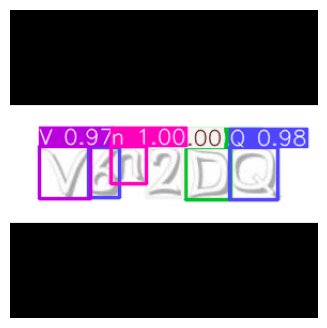

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.imshow(pred[0].plot())
plt.axis("off")
plt.show()


# test

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[253, 255, 255],
        [253, 255, 255],
        [253, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
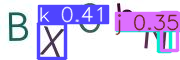

In [23]:
img_path = "/content/drive/MyDrive/Colab Notebooks/captcha_yolo_project/datasets/captcha1.png"  # adapte le chemin
pred = model.predict(img_path, conf=0.25, imgsz=640)
pred[0].plot()


array([[[ 64,  64,  64],
        [ 64,  64,  64],
        [ 65,  65,  65],
        ...,
        [231, 231, 231],
        [231, 231, 231],
        [232, 232, 232]],

       [[ 64,  64,  64],
        [ 64,  64,  64],
        [ 65,  65,  65],
        ...,
        [231, 231, 231],
        [232, 232, 232],
        [233, 233, 233]],

       [[ 64,  64,  64],
        [ 64,  64,  64],
        [ 66,  66,  66],
        ...,
        [231, 231, 231],
        [232, 232, 232],
        [233, 233, 233]],

       ...,

       [[ 83,  83,  83],
        [ 84,  84,  84],
        [ 85,  85,  85],
        ...,
        [251, 251, 251],
        [252, 252, 252],
        [252, 252, 252]],

       [[ 84,  84,  84],
        [ 84,  84,  84],
        [ 85,  85,  85],
        ...,
        [251, 251, 251],
        [252, 252, 252],
        [253, 253, 253]],

       [[ 84,  84,  84],
        [ 84,  84,  84],
        [ 85,  85,  85],
        ...,
        [252, 252, 252],
        [252, 252, 252],
        [253, 253, 253]]], dtype=uint8)
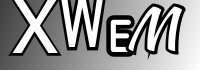

In [24]:
img_path = "/content/drive/MyDrive/Colab Notebooks/captcha_yolo_project/datasets/captcha2.png"  # adapte le chemin
pred = model.predict(img_path, conf=0.25, imgsz=640)
pred[0].plot()

# 5) Prédire et reconstruire le texte (1 ligne)

YOLO détecte des **caractères** (boîtes + classe + confiance), mais ne renvoie pas directement un "mot".

Dans cette étape, on va :
1. Charger le modèle `best.pt` depuis Google Drive
2. Charger la liste des classes (`names`) depuis `data.yaml`
3. Faire une prédiction sur une image test
4. Reconstruire le texte en triant les boîtes de gauche à droite (tri par `x_center`)
5. Afficher l'image annotée + le texte reconstruit


In [8]:
# ============================================
# CHARGER LE MODÈLE + LES CLASSES
# ============================================

from ultralytics import YOLO
import yaml
from pathlib import Path

# (1) Chemin du modèle entraîné (dans ton Drive)
MODEL_PATH = Path("/content/drive/MyDrive/Colab Notebooks/captcha_yolo_project/models/best.pt")

# (2) Chemin du data.yaml du dataset Roboflow (dans /content si tu l'as encore téléchargé)
DATA_YAML_PATH = Path("/content/datasets/Yolo-Captcha-Test-7/data.yaml")

print("Modèle:", MODEL_PATH, "| existe =", MODEL_PATH.exists())
print("data.yaml:", DATA_YAML_PATH, "| existe =", DATA_YAML_PATH.exists())

# Charger le modèle YOLO
model = YOLO(str(MODEL_PATH))
print("✅ Modèle chargé")

# Charger les classes (names) depuis data.yaml
with open(DATA_YAML_PATH, "r", encoding="utf-8") as f:
    data_cfg = yaml.safe_load(f)

names = data_cfg["names"]   # liste: id -> caractère
nc = data_cfg["nc"]         # nombre de classes

print("✅ nc =", nc, "| nb(names) =", len(names))
print("Exemples names:", names[:10], "...", names[-10:])


Modèle: /content/drive/MyDrive/Colab Notebooks/captcha_yolo_project/models/best.pt | existe = True
data.yaml: /content/datasets/Yolo-Captcha-Test-7/data.yaml | existe = True
✅ Modèle chargé
✅ nc = 62 | nb(names) = 62
Exemples names: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'] ... ['q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


## 5.2 Tester une image et visualiser les boxes

On sélectionne une image test aléatoire, on lance `model.predict()`, puis on affiche l'image avec les boîtes.


🖼️ Image test : 688385614349_jpg.rf.e0985b8d529d5768452ebafbbafe798d.jpg


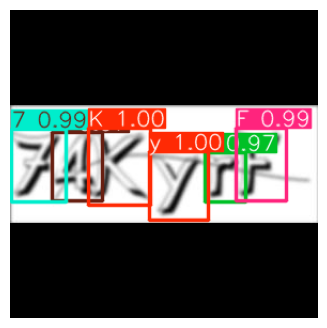

In [9]:
# ============================================
# 5.2) PRÉDICTION + AFFICHAGE
# ============================================

import glob
import random
import matplotlib.pyplot as plt
from pathlib import Path

# On prend une image au hasard dans le split test
test_images = glob.glob("/content/datasets/Yolo-Captcha-Test-7/test/images/*")
assert len(test_images) > 0, "❌ Aucune image trouvée dans test/images"

img_path = random.choice(test_images)
print("🖼️ Image test :", Path(img_path).name)

# Prédire
pred = model.predict(
    img_path,
    conf=0.25,     # seuil de confiance (on garde les boxes >= 0.25)
    imgsz=640,     # taille d'entrée du modèle (redimensionnement)
    verbose=False  # moins de logs dans la console
)

# pred est une liste (1 élément si on donne 1 image)
result = pred[0]

# Afficher l'image annotée (boxes + labels + conf)
plt.figure(figsize=(12, 4))
plt.imshow(result.plot())
plt.axis("off")
plt.show()


## 5.3 Reconstruire le texte (tri gauche → droite)

Principe :
- pour chaque boîte détectée, on récupère le centre `x_center`
- on trie les caractères du plus petit `x_center` (gauche) au plus grand (droite)
- on concatène pour former le texte

⚠️ Ceci suppose un CAPTCHA sur **une seule ligne**.


In [10]:
# ============================================
# 5.3) RECONSTRUIRE LE TEXTE (1 LIGNE)
# ============================================

def decode_1line_yolo(result, names, conf_threshold=0.25):
    """
    Transforme une sortie YOLO (result) en texte (1 ligne).
    - Filtre les boxes dont la confiance < conf_threshold
    - Trie les caractères de gauche à droite selon x_center
    - Concatène les caractères
    """
    boxes = result.boxes
    if boxes is None or len(boxes) == 0:
        return ""

    items = []

    for b in boxes:
        # confiance de la détection
        conf = float(b.conf)
        if conf < conf_threshold:
            continue

        # classe prédite (id) -> caractère (via names)
        cls_id = int(b.cls)
        char = names[cls_id]

        # coordonnées de la box (x1, y1, x2, y2)
        x1, y1, x2, y2 = map(float, b.xyxy[0])

        # centre en x pour trier gauche -> droite
        x_center = (x1 + x2) / 2.0

        items.append((x_center, char, conf))

    # tri gauche -> droite
    items.sort(key=lambda t: t[0])

    # concatène uniquement les caractères (on ignore conf ici)
    text = "".join(ch for _, ch, _ in items)

    return text, items

text, items = decode_1line_yolo(result, names, conf_threshold=0.25)

print("🔤 Texte reconstruit :", text)
print("\nDétails (x_center, char, conf):")
for xc, ch, cf in items:
    print(f" - x={xc:.1f} | {ch} | conf={cf:.2f}")


🔤 Texte reconstruit : 74KyrF

Détails (x_center, char, conf):
 - x=27.1 | 7 | conf=0.99
 - x=63.1 | 4 | conf=0.97
 - x=102.6 | K | conf=1.00
 - x=157.9 | y | conf=1.00
 - x=201.4 | r | conf=0.97
 - x=235.0 | F | conf=0.99


# 6) Nettoyage des doublons (anti "AA")

Pourquoi ?
YOLO peut parfois sortir **plusieurs boxes** pour un même caractère (doublons),
ou plusieurs boxes très proches/chevauchantes.

On va donc :
1. Filtrer les boxes par confiance (`conf_threshold`)
2. Supprimer les doublons avec une règle simple :
   - Si deux boxes se chevauchent beaucoup (IoU élevé),
     on garde celle qui a la plus grande confiance.
3. Trier les boxes restantes de gauche à droite
4. Reconstruire le texte final

➡️ Résultat : un texte plus propre, avec moins de répétitions.


In [11]:
# ============================================
# 6.1) DÉDOUBLONNAGE + RECONSTRUCTION DU TEXTE
# ============================================

import numpy as np

def iou_xyxy(a, b):
    """
    Calcule l'IoU (Intersection over Union) entre 2 boxes au format [x1,y1,x2,y2].
    IoU proche de 1 => boxes quasi identiques
    IoU proche de 0 => boxes très différentes
    """
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b

    # Intersection
    ix1 = max(ax1, bx1)
    iy1 = max(ay1, by1)
    ix2 = min(ax2, bx2)
    iy2 = min(ay2, by2)

    iw = max(0.0, ix2 - ix1)
    ih = max(0.0, iy2 - iy1)
    inter = iw * ih

    # Aires
    area_a = max(0.0, (ax2 - ax1)) * max(0.0, (ay2 - ay1))
    area_b = max(0.0, (bx2 - bx1)) * max(0.0, (by2 - by1))

    # Union
    union = area_a + area_b - inter
    if union <= 0:
        return 0.0

    return inter / union


def clean_duplicates(result, names, conf_threshold=0.25, iou_threshold=0.6):
    """
    Nettoie les détections YOLO pour enlever les doublons.

    Étapes :
    1) Récupérer toutes les boxes et garder seulement celles avec conf >= conf_threshold
    2) Trier les boxes par confiance décroissante
    3) Garder une box, supprimer toutes celles qui se chevauchent trop (IoU >= iou_threshold)
       -> On garde la meilleure (confiance la plus élevée)
    Retour :
      - kept : liste de dicts {box, conf, cls_id, char, x_center}
    """
    boxes = result.boxes
    if boxes is None or len(boxes) == 0:
        return []

    # 1) Construire une liste simple de détections (Python natif)
    dets = []
    for b in boxes:
        conf = float(b.conf)
        if conf < conf_threshold:
            continue

        cls_id = int(b.cls)
        char = names[cls_id]

        x1, y1, x2, y2 = map(float, b.xyxy[0])
        x_center = (x1 + x2) / 2.0

        dets.append({
            "box": [x1, y1, x2, y2],
            "conf": conf,
            "cls_id": cls_id,
            "char": char,
            "x_center": x_center
        })

    if not dets:
        return []

    # 2) Trier par confiance décroissante (on garde d'abord les plus fiables)
    dets.sort(key=lambda d: d["conf"], reverse=True)

    # 3) NMS "maison" : on supprime les boxes qui chevauchent trop une box gardée
    kept = []
    for d in dets:
        keep = True
        for k in kept:
            if iou_xyxy(d["box"], k["box"]) >= iou_threshold:
                keep = False
                break
        if keep:
            kept.append(d)

    return kept


def decode_1line_clean(result, names, conf_threshold=0.25, iou_threshold=0.6):
    """
    Pipeline complet (1 ligne) :
    - nettoyage des doublons (IoU)
    - tri gauche -> droite
    - reconstruction du texte
    """
    kept = clean_duplicates(result, names, conf_threshold=conf_threshold, iou_threshold=iou_threshold)

    # Trier gauche -> droite
    kept.sort(key=lambda d: d["x_center"])

    # Concaténer
    text = "".join(d["char"] for d in kept)

    return text, kept


# ======= TEST sur la prédiction "result" déjà calculée (cellule précédente) =======
# (assure-toi d'avoir : result et names disponibles)

text_clean, kept = decode_1line_clean(result, names, conf_threshold=0.25, iou_threshold=0.6)

print("🔤 Texte reconstruit (AVEC nettoyage) :", text_clean)
print("\nDétails après nettoyage :")
for d in kept:
    print(f" - {d['char']} | conf={d['conf']:.2f} | box={tuple(round(x,1) for x in d['box'])}")


🔤 Texte reconstruit (AVEC nettoyage) : 74KyrF

Détails après nettoyage :
 - 7 | conf=0.99 | box=(1.3, 111.8, 53.0, 179.2)
 - 4 | conf=0.97 | box=(39.3, 114.5, 86.9, 178.5)
 - K | conf=1.00 | box=(73.5, 110.6, 131.7, 182.2)
 - y | conf=1.00 | box=(130.4, 132.1, 185.3, 196.3)
 - r | conf=0.97 | box=(182.1, 133.1, 220.7, 179.1)
 - F | conf=0.99 | box=(211.2, 110.5, 258.8, 178.6)


# 7) Métriques OCR : Exact Match & CER

Pourquoi ?
- Les métriques YOLO (mAP) mesurent la qualité des **boîtes**.
- Nous, on veut mesurer la qualité du **texte final** (le "mot" CAPTCHA).

On calcule :
1. **Exact Match Accuracy** : % d'images où le mot reconstruit est EXACTEMENT correct
2. **CER (Character Error Rate)** : proportion d'erreurs au niveau caractère (distance d'édition / longueur)

Principe :
- Ground Truth (GT) : on reconstruit le mot à partir des labels `.txt` (YOLO) en triant par x.
- Prediction : on reconstruit le mot à partir des boxes prédites (YOLO) en triant par x.
- On compare GT vs Pred.


In [12]:
# ============================================
# 7.1) PARAMÈTRES + CHARGEMENT CLASSES
# ============================================

from pathlib import Path
import yaml

# Dataset Roboflow dans /content (adapte si ton chemin change)
DATASET_DIR = Path("/content/datasets/Yolo-Captcha-Test-7")

# Split à évaluer: "valid" ou "test"
SPLIT = "test"

# Chemins images/labels pour le split
IMG_DIR = DATASET_DIR / SPLIT / "images"
LAB_DIR = DATASET_DIR / SPLIT / "labels"

# data.yaml (contient la liste des classes dans l'ordre)
DATA_YAML = DATASET_DIR / "data.yaml"

print("IMG_DIR:", IMG_DIR, "| existe =", IMG_DIR.exists())
print("LAB_DIR:", LAB_DIR, "| existe =", LAB_DIR.exists())
print("data.yaml:", DATA_YAML, "| existe =", DATA_YAML.exists())

assert IMG_DIR.exists() and LAB_DIR.exists() and DATA_YAML.exists(), "❌ Chemins dataset incorrects"

# Charger les classes
with open(DATA_YAML, "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)
names = cfg["names"]
print("✅ nb classes:", len(names))


IMG_DIR: /content/datasets/Yolo-Captcha-Test-7/test/images | existe = True
LAB_DIR: /content/datasets/Yolo-Captcha-Test-7/test/labels | existe = True
data.yaml: /content/datasets/Yolo-Captcha-Test-7/data.yaml | existe = True
✅ nb classes: 62


## 7.2 Fonctions : reconstruire GT et Prédiction

On fait la même logique des deux côtés :
- calcul du centre `x_center`
- tri gauche → droite
- concaténation des caractères

Ainsi, la comparaison est "juste".


In [13]:
# ============================================
# 7.2) RECONSTRUCTION DU TEXTE (GT & PRED)
# ============================================

import glob
import random
from ultralytics import YOLO

# Charger ton modèle depuis Drive
MODEL_PATH = "/content/drive/MyDrive/Colab Notebooks/captcha_yolo_project/models/best.pt"
model = YOLO(MODEL_PATH)

def decode_from_yolo_labels(label_path: Path, names):
    """
    Reconstruit le texte GT à partir d'un fichier label YOLO (.txt).
    Format YOLO: class x_center y_center w h (normalisé)
    On trie par x_center (déjà donné dans le fichier).
    """
    if not label_path.exists():
        return ""

    items = []
    for line in label_path.read_text().strip().splitlines():
        parts = line.split()
        if len(parts) != 5:
            continue
        cls_id = int(float(parts[0]))
        x_center = float(parts[1])  # normalisé 0..1, suffisant pour trier
        items.append((x_center, names[cls_id]))

    items.sort(key=lambda t: t[0])
    return "".join(ch for _, ch in items)


def decode_from_prediction(result, names, conf=0.25):
    """
    Reconstruit le texte prédit à partir de la sortie YOLO.
    - Filtre par confiance
    - Trie par x_center
    """
    boxes = result.boxes
    if boxes is None or len(boxes) == 0:
        return ""

    items = []
    for b in boxes:
        if float(b.conf) < conf:
            continue
        cls_id = int(b.cls)
        x1, y1, x2, y2 = map(float, b.xyxy[0])
        x_center = (x1 + x2) / 2.0
        items.append((x_center, names[cls_id]))

    items.sort(key=lambda t: t[0])
    return "".join(ch for _, ch in items)


## 7.3 CER (Character Error Rate)

CER = (distance d'édition entre prédiction et vérité) / (nb de caractères vérité)

Distance d'édition = nb minimal d'opérations pour transformer Pred -> GT :
- insertion
- suppression
- substitution

CER = 0  → parfait
CER = 0.2 → en moyenne 20% de caractères "faux"


In [14]:
# ============================================
# 7.3) DISTANCE D'ÉDITION (LEVENSHTEIN) + CER
# ============================================

def levenshtein(a: str, b: str) -> int:
    """Distance d'édition Levenshtein (DP classique)."""
    if a == b:
        return 0
    if len(a) == 0:
        return len(b)
    if len(b) == 0:
        return len(a)

    # dp[i][j] = distance entre a[:i] et b[:j]
    dp = list(range(len(b) + 1))

    for i in range(1, len(a) + 1):
        prev = dp[0]
        dp[0] = i
        for j in range(1, len(b) + 1):
            temp = dp[j]
            cost = 0 if a[i-1] == b[j-1] else 1
            dp[j] = min(
                dp[j] + 1,      # suppression
                dp[j-1] + 1,    # insertion
                prev + cost     # substitution
            )
            prev = temp
    return dp[-1]


def cer(pred: str, gt: str) -> float:
    """Character Error Rate = lev(pred, gt) / len(gt) (si gt non vide)."""
    if len(gt) == 0:
        return 0.0 if len(pred) == 0 else 1.0
    return levenshtein(pred, gt) / len(gt)


## 7.4 Évaluer sur un mini set (rapide)

On évalue sur un petit échantillon (ex: 50 images) pour aller vite :
- Exact Match Accuracy
- CER moyen

On affichera aussi quelques exemples d'erreurs (GT vs Pred) pour comprendre.


In [15]:
# ============================================
# 7.4) ÉVALUATION OCR SUR UN MINI SET
# ============================================

import numpy as np

# Paramètres d'évaluation
N_SAMPLES = 50      # mets 200 ou + si tu veux plus fiable
CONF = 0.25         # même seuil que tes tests
IMGSZ = 640         # idem

# Liste des images disponibles
img_paths = sorted(glob.glob(str(IMG_DIR / "*")))
assert len(img_paths) > 0, "❌ Aucun fichier image trouvé"

# On prend un échantillon aléatoire
sample_paths = random.sample(img_paths, k=min(N_SAMPLES, len(img_paths)))

exact_matches = 0
cers = []
examples = []  # pour stocker quelques erreurs

for img_path in sample_paths:
    img_path = Path(img_path)
    label_path = LAB_DIR / f"{img_path.stem}.txt"

    # Ground truth depuis labels YOLO
    gt_text = decode_from_yolo_labels(label_path, names)

    # Prediction
    res = model.predict(str(img_path), conf=CONF, imgsz=IMGSZ, verbose=False)[0]
    pred_text = decode_from_prediction(res, names, conf=CONF)

    # Metrics
    if pred_text == gt_text:
        exact_matches += 1

    c = cer(pred_text, gt_text)
    cers.append(c)

    # stocker quelques exemples d'erreurs
    if pred_text != gt_text and len(examples) < 8:
        examples.append((img_path.name, gt_text, pred_text, c))

acc = exact_matches / len(sample_paths)
mean_cer = float(np.mean(cers))

print(f"✅ OCR Exact Match Accuracy: {acc:.3f}  ({exact_matches}/{len(sample_paths)})")
print(f"✅ CER moyen: {mean_cer:.3f}")

print("\n📌 Exemples d'erreurs (nom, GT, Pred, CER):")
for name, gt, pr, c in examples:
    print(f"- {name}: GT='{gt}' | Pred='{pr}' | CER={c:.3f}")


✅ OCR Exact Match Accuracy: 0.700  (35/50)
✅ CER moyen: 0.069

📌 Exemples d'erreurs (nom, GT, Pred, CER):
- 787_jpg.rf.cdc0195e107f485ca2a2d83c000bb306.jpg: GT='g309SJ' | Pred='g309S3J' | CER=0.167
- 377350414831_jpg.rf.a9eab74830aa84073e10a6c60b9039ff.jpg: GT='F233Im' | Pred='F23333lIm' | CER=0.500
- 606735198782_jpg.rf.0651071a16d41858790e5a1c71763b2f.jpg: GT='IIaEV1' | Pred='IllIaEV1' | CER=0.333
- 1288_jpg.rf.9f475425fc3c7c916b2548cfe9603f96.jpg: GT='48fUro' | Pred='48Uro' | CER=0.167
- 342f74eeae3a42f4a5f5ff34dc723ddd_jpg.rf.f555e854b1a31f806f13f27f69635b81.jpg: GT='DcoQiJ' | Pred='DcoQi' | CER=0.167
- 303330249854_jpg.rf.54125b46bf468e78576767e0608a3150.jpg: GT='mIXP35' | Pred='mlXP35' | CER=0.167
- 467_jpg.rf.beb39dece0f564901fbee1b6ca040505.jpg: GT='d5XlrP' | Pred='d5XP' | CER=0.333
- 2250cd973820496ebe3cda88525b9853_jpg.rf.8c8b5068eff797e710ed665cccc0b07a.jpg: GT='ryrNhS' | Pred='ryrNhS3' | CER=0.167


# 8) Améliorer l'inférence : comparaison `imgsz` et `conf`

Objectif :
- Voir si augmenter la taille d'entrée (`imgsz`) améliore la lecture du texte
- Voir l'effet du seuil de confiance (`conf`) sur Exact Match et CER

On teste plusieurs combos :
- imgsz ∈ {640, 960, 1280}
- conf ∈ {0.10, 0.25, 0.35}

On garde la meilleure configuration (Exact Match max, CER min).


In [16]:
# ============================================
# 8.1) GRID SEARCH RAPIDE (mini set)
# ============================================

import glob, random, numpy as np
from pathlib import Path

# Reprend les fonctions déjà définies :
# - decode_from_yolo_labels(label_path, names)
# - decode_from_prediction(result, names, conf=...)
# - cer(pred, gt)

# Paramètres
N_SAMPLES = 100  # augmente si tu veux (200) mais 100 suffit pour décider vite

img_paths = sorted(glob.glob(str(IMG_DIR / "*")))
sample_paths = random.sample(img_paths, k=min(N_SAMPLES, len(img_paths)))

grid_imgsz = [640, 960, 1280]
grid_conf  = [0.10, 0.25, 0.35]

results_grid = []

for imgsz in grid_imgsz:
    for conf_th in grid_conf:
        exact = 0
        cers = []

        for p in sample_paths:
            p = Path(p)
            gt = decode_from_yolo_labels(LAB_DIR / f"{p.stem}.txt", names)

            res = model.predict(str(p), conf=conf_th, imgsz=imgsz, verbose=False)[0]
            pred_txt = decode_from_prediction(res, names, conf=conf_th)

            if pred_txt == gt:
                exact += 1
            cers.append(cer(pred_txt, gt))

        acc = exact / len(sample_paths)
        mean_cer = float(np.mean(cers))

        results_grid.append((imgsz, conf_th, acc, mean_cer))
        print(f"imgsz={imgsz} conf={conf_th:.2f} -> ExactMatch={acc:.3f} | CER={mean_cer:.3f}")

# Trier : meilleur ExactMatch d'abord, puis CER le plus bas
results_grid.sort(key=lambda x: (-x[2], x[3]))

print("\n🏆 Top 5 configs:")
for r in results_grid[:5]:
    print(f"imgsz={r[0]} conf={r[1]:.2f} | ExactMatch={r[2]:.3f} | CER={r[3]:.3f}")


imgsz=640 conf=0.10 -> ExactMatch=0.430 | CER=0.141
imgsz=640 conf=0.25 -> ExactMatch=0.610 | CER=0.083
imgsz=640 conf=0.35 -> ExactMatch=0.640 | CER=0.073
imgsz=960 conf=0.10 -> ExactMatch=0.260 | CER=0.236
imgsz=960 conf=0.25 -> ExactMatch=0.520 | CER=0.120
imgsz=960 conf=0.35 -> ExactMatch=0.620 | CER=0.093
imgsz=1280 conf=0.10 -> ExactMatch=0.020 | CER=0.772
imgsz=1280 conf=0.25 -> ExactMatch=0.040 | CER=0.513
imgsz=1280 conf=0.35 -> ExactMatch=0.040 | CER=0.482

🏆 Top 5 configs:
imgsz=640 conf=0.35 | ExactMatch=0.640 | CER=0.073
imgsz=960 conf=0.35 | ExactMatch=0.620 | CER=0.093
imgsz=640 conf=0.25 | ExactMatch=0.610 | CER=0.083
imgsz=960 conf=0.25 | ExactMatch=0.520 | CER=0.120
imgsz=640 conf=0.10 | ExactMatch=0.430 | CER=0.141


# 9) Évaluation complète sur tout le split (test ou valid)

Maintenant qu'on a une bonne config (imgsz/conf),
on évalue sur **toutes les images** du split pour obtenir des métriques fiables.

On calcule :
- Exact Match Accuracy global
- CER moyen + médiane + percentiles (P90, P95)
- Liste des erreurs les plus fréquentes


In [17]:
# ============================================
# 9.1) FULL EVAL SUR TOUT LE SPLIT
# ============================================

import numpy as np
from collections import Counter

# Choisis ici la meilleure config issue de la grille
BEST_IMGSZ = 640
BEST_CONF  = 0.35

img_paths = sorted(glob.glob(str(IMG_DIR / "*")))
print("Nb images dans le split:", len(img_paths))

exact = 0
cers = []
errors = []  # (filename, gt, pred, cer)
confusions = Counter()  # pour compter les couples (gt_char, pred_char)

for p in img_paths:
    p = Path(p)
    gt = decode_from_yolo_labels(LAB_DIR / f"{p.stem}.txt", names)

    res = model.predict(str(p), conf=BEST_CONF, imgsz=BEST_IMGSZ, verbose=False)[0]
    pred_txt = decode_from_prediction(res, names, conf=BEST_CONF)

    if pred_txt == gt:
        exact += 1

    c = cer(pred_txt, gt)
    cers.append(c)

    if pred_txt != gt:
        errors.append((p.name, gt, pred_txt, c))

        # mini analyse de confusions caractère par caractère (alignement naïf)
        # (Pas parfait, mais donne une idée rapide)
        L = min(len(gt), len(pred_txt))
        for i in range(L):
            if gt[i] != pred_txt[i]:
                confusions[(gt[i], pred_txt[i])] += 1

acc = exact / len(img_paths)
cers = np.array(cers)

print("\n✅ Résultats OCR (full split)")
print(f"- Exact Match Accuracy : {acc:.3f} ({exact}/{len(img_paths)})")
print(f"- CER moyen            : {cers.mean():.3f}")
print(f"- CER médian           : {np.median(cers):.3f}")
print(f"- CER P90              : {np.percentile(cers, 90):.3f}")
print(f"- CER P95              : {np.percentile(cers, 95):.3f}")
print(f"- Nb erreurs           : {len(errors)}")

print("\n🔁 Top 10 confusions (gt -> pred):")
for (g, pr), n in confusions.most_common(10):
    print(f"- '{g}' -> '{pr}' : {n} fois")


Nb images dans le split: 340

✅ Résultats OCR (full split)
- Exact Match Accuracy : 0.668 (227/340)
- CER moyen            : 0.067
- CER médian           : 0.000
- CER P90              : 0.167
- CER P95              : 0.200
- Nb erreurs           : 113

🔁 Top 10 confusions (gt -> pred):
- 'l' -> 'I' : 23 fois
- 'I' -> 'l' : 8 fois
- 'c' -> 'l' : 3 fois
- 'X' -> 'l' : 2 fois
- 'j' -> 'i' : 2 fois
- 'H' -> 'l' : 2 fois
- 'h' -> '0' : 2 fois
- 'v' -> 'X' : 2 fois
- 'y' -> 'O' : 2 fois
- 't' -> 'i' : 2 fois


## 9.2 Afficher les pires erreurs

On affiche les exemples avec le CER le plus élevé
pour comprendre visuellement ce qui pose problème.


📌 Top 10 pires erreurs :
- 1162_jpg.rf.54bee9dee1e7624f16da3426086dfc2a.jpg | GT='Qvrdkl' | Pred='QvrdddkI' | CER=0.500
- 1166_jpg.rf.cb0dbaa00b132025fe3bd3a8121b45e7.jpg | GT='L3lIQQ' | Pred='L3lIIQQQQ' | CER=0.500
- 151_jpg.rf.c6cc6f342573f935178482177b19c5da.jpg | GT='ioSi2P' | Pred='S2P' | CER=0.500
- 377350414831_jpg.rf.a9eab74830aa84073e10a6c60b9039ff.jpg | GT='F233Im' | Pred='F23333lIm' | CER=0.500
- 1007520985440_jpg.rf.01db2678792b5306f423e36156b99669.jpg | GT='IX2Y0' | Pred='IlX2Y0Q' | CER=0.400
- 1177206239374_jpg.rf.66794922f3f5e899ad5ba30f2dccf5e5.jpg | GT='IxvNW' | Pred='lIxvNWB' | CER=0.400
- 1220_jpg.rf.cd585df5da3c3c3e10cc5434f4d03f65.jpg | GT='o7wWQ' | Pred='o7wWQNN' | CER=0.400
- 1249928351040_jpg.rf.c13668d1b32c4982be427848ef8c87ff.jpg | GT='7l1UT' | Pred='7I1UTV' | CER=0.400
- 12_jpg.rf.2579fc8da0488e0bf32199f2f8e2e5cf.jpg | GT='raDUIH' | Pred='nraDUlIH' | CER=0.333
- 319_jpg.rf.4fd378cdc3f49f7bf79bc0c4e90ba9c8.jpg | GT='ePhqgk' | Pred='ePhk' | CER=0.333


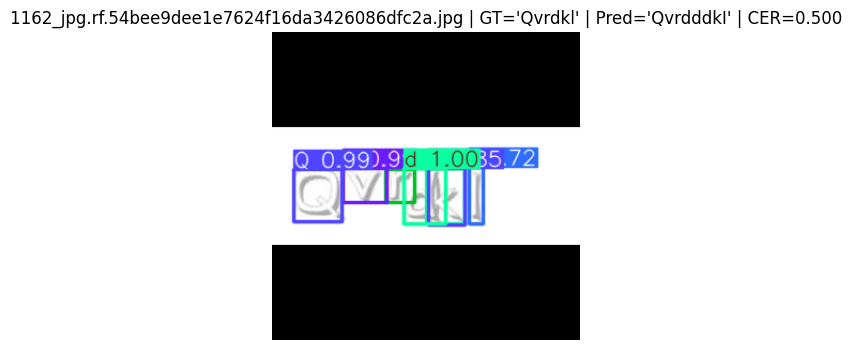

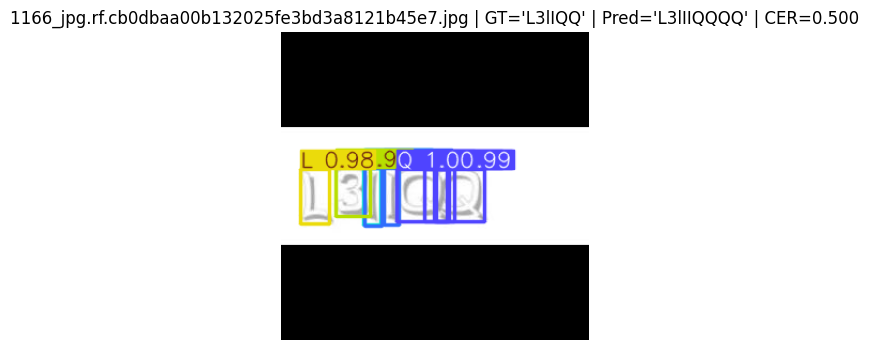

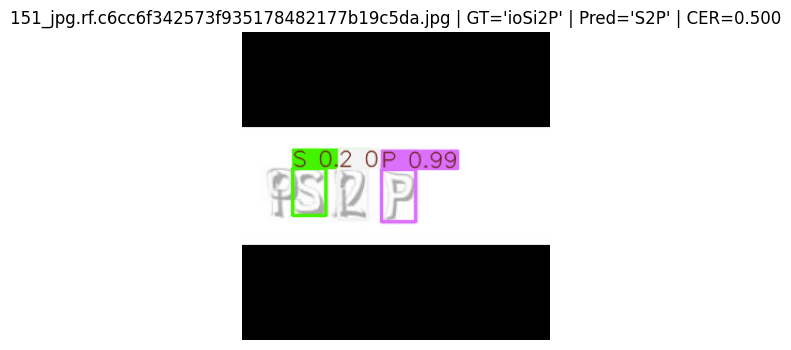

In [18]:
# ============================================
# 9.2) TOP ERREURS + VISUALISATION
# ============================================

import matplotlib.pyplot as plt

# Trier par CER décroissant (pires d'abord)
errors_sorted = sorted(errors, key=lambda x: x[3], reverse=True)

print("📌 Top 10 pires erreurs :")
for e in errors_sorted[:10]:
    print(f"- {e[0]} | GT='{e[1]}' | Pred='{e[2]}' | CER={e[3]:.3f}")

# Afficher 3 exemples (tu peux augmenter)
for name, gt, pr, c in errors_sorted[:3]:
    img_file = str(IMG_DIR / name)
    res = model.predict(img_file, conf=BEST_CONF, imgsz=BEST_IMGSZ, verbose=False)[0]

    plt.figure(figsize=(12, 4))
    plt.title(f"{name} | GT='{gt}' | Pred='{pr}' | CER={c:.3f}")
    plt.imshow(res.plot())
    plt.axis("off")
    plt.show()
